Real Time Academic Performance Prediction System Using Machine Learning.

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('xAPI-Edu-Data.csv')

In [3]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


## 2. Data Preprocessing

Before we can train any machine learning model, we need to preprocess our data. This involves several steps:
1.  **Clean Column Names**: Ensure column names are consistent and easy to work with.
2.  **Categorical Feature Encoding**: Convert categorical variables into numerical representations.
3.  **Feature Scaling (if necessary)**: Standardize or normalize numerical features.
4.  **Data Splitting**: Divide the dataset into training and testing sets.

In [4]:
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

print("Cleaned column names:", df.columns.tolist())

Cleaned column names: ['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class']


### 2.1 Categorical Feature Encoding

Many columns in our dataset are categorical. We need to convert them into a numerical format. For our target variable `Class`, we'll use `LabelEncoder`. For other nominal categorical features, we'll use `OneHotEncoder` to avoid introducing spurious order.

In [5]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Identify categorical columns (excluding the target variable 'Class')
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove('Class') # Remove target variable

# Apply Label Encoding to the target variable 'Class'
le = LabelEncoder()
df['Class_encoded'] = le.fit_transform(df['Class'])

print("Original Class labels:", le.classes_)
print("Encoded Class values (0, 1, 2 for L, M, H respectively):", df['Class_encoded'].unique())


Original Class labels: ['H' 'L' 'M']
Encoded Class values (0, 1, 2 for L, M, H respectively): [2 1 0]


In [6]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import pandas as pd # Ensure pandas is imported if not globally available

# Apply One-Hot Encoding to the remaining categorical features
# Use ColumnTransformer for robust encoding

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Keep numerical columns as they are for now
)

# Fit and transform the data
X = df.drop(['Class', 'Class_encoded'], axis=1) # Features, excluding original and encoded target
y = df['Class_encoded'] # Target variable

X_processed = preprocessor.fit_transform(X)

# Get all new feature names after one-hot encoding and passthrough
final_feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame with processed features
X_processed_df = pd.DataFrame(X_processed, columns=final_feature_names)

print(f"Shape of processed features: {X_processed_df.shape}")
display(X_processed_df.head())

Shape of processed features: (480, 72)


,cat__gender_F,cat__gender_M,cat__NationalITy_Egypt,cat__NationalITy_Iran,cat__NationalITy_Iraq,cat__NationalITy_Jordan,cat__NationalITy_KW,cat__NationalITy_Lybia,cat__NationalITy_Morocco,cat__NationalITy_Palestine,...,cat__ParentAnsweringSurvey_No,cat__ParentAnsweringSurvey_Yes,cat__ParentschoolSatisfaction_Bad,cat__ParentschoolSatisfaction_Good,cat__StudentAbsenceDays_Above-7,cat__StudentAbsenceDays_Under-7,remainder__raisedhands,remainder__VisITedResources,remainder__AnnouncementsView,remainder__Discussion
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,15.0,16.0,2.0,20.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,20.0,20.0,3.0,25.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,10.0,7.0,0.0,30.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,30.0,25.0,5.0,35.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,40.0,50.0,12.0,50.0


In [7]:
df['Class'].value_counts()

,count
Class,
M,211
H,142
L,127


### 2.2 Data Splitting

Now, we'll split our processed data into training and testing sets. This allows us to train the model on one portion of the data and evaluate its performance on unseen data.

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (384, 72)
X_test shape: (96, 72)
y_train shape: (384,)
y_test shape: (96,)


In [9]:
# Re-executing the fixed data preprocessing cell (a2ed76ba) to ensure X_processed_df is correctly created
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X = df.drop(['Class', 'Class_encoded'], axis=1)
y = df['Class_encoded']

X_processed = preprocessor.fit_transform(X)

final_feature_names = preprocessor.get_feature_names_out()
X_processed_df = pd.DataFrame(X_processed, columns=final_feature_names)

print(f"Shape of processed features: {X_processed_df.shape}")
display(X_processed_df.head())

Shape of processed features: (480, 72)


,cat__gender_F,cat__gender_M,cat__NationalITy_Egypt,cat__NationalITy_Iran,cat__NationalITy_Iraq,cat__NationalITy_Jordan,cat__NationalITy_KW,cat__NationalITy_Lybia,cat__NationalITy_Morocco,cat__NationalITy_Palestine,...,cat__ParentAnsweringSurvey_No,cat__ParentAnsweringSurvey_Yes,cat__ParentschoolSatisfaction_Bad,cat__ParentschoolSatisfaction_Good,cat__StudentAbsenceDays_Above-7,cat__StudentAbsenceDays_Under-7,remainder__raisedhands,remainder__VisITedResources,remainder__AnnouncementsView,remainder__Discussion
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,15.0,16.0,2.0,20.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,20.0,20.0,3.0,25.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,10.0,7.0,0.0,30.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,30.0,25.0,5.0,35.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,40.0,50.0,12.0,50.0


In [10]:
# Re-executing the data splitting cell (c861581b) to define X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (384, 72)
X_test shape: (96, 72)
y_train shape: (384,)
y_test shape: (96,)


## 3. Model Training and Evaluation

With our data preprocessed and split, we can now train a machine learning model to predict student performance (`Class`). We'll use a **RandomForestClassifier**, which is a powerful ensemble method suitable for classification tasks. After training, we will evaluate its performance using key metrics like accuracy, precision, recall, F1-score, and visualize the confusion matrix.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Random Forest Classifier
# Using a random_state for reproducibility
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
print("Training the RandomForestClassifier...")
model.fit(X_train, y_train)
print("Training complete.")

Training the RandomForestClassifier...
Training complete.


### 3.1 Model Prediction and Evaluation Metrics

Now we'll use the trained model to make predictions on our test set and evaluate its performance.

In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_)) # Use original class labels for clarity

Model Accuracy: 0.7917

Classification Report:
              precision    recall  f1-score   support

           H       0.81      0.72      0.76        29
           L       0.88      0.84      0.86        25
           M       0.74      0.81      0.77        42

    accuracy                           0.79        96
   macro avg       0.81      0.79      0.80        96
weighted avg       0.80      0.79      0.79        96



### 3.2 Confusion Matrix Chart

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. This is particularly useful for understanding the types of errors our model is making.

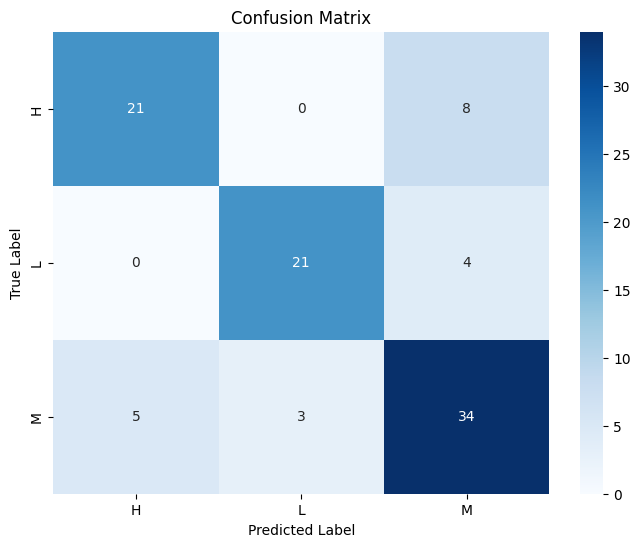

In [13]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 4. Save the Trained Model

To ensure our trained model can be used for future predictions or deployments without retraining, we will save it to disk using the `joblib` library. This is a common practice for machine learning models.

In [38]:
import joblib

# Define the filename for the model
model_filename = 'academic_performance_model_RF.joblib'

# Save the trained model
joblib.dump(model, model_filename)

print(f"Model successfully saved to {model_filename}")

Model successfully saved to academic_performance_model_RF.joblib


## 3. Model Training and Evaluation

With our data preprocessed and split, we can now train a machine learning model to predict student performance (`Class`). We'll use a **RandomForestClassifier**, which is a powerful ensemble method suitable for classification tasks. After training, we will evaluate its performance using key metrics like accuracy, precision, recall, F1-score, and visualize the confusion matrix.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Random Forest Classifier
# Using a random_state for reproducibility
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
print("Training the RandomForestClassifier...")
model.fit(X_train, y_train)
print("Training complete.")

Training the RandomForestClassifier...
Training complete.


### 3.1 Model Prediction and Evaluation Metrics

Now we'll use the trained model to make predictions on our test set and evaluate its performance.

In [16]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_)) # Use original class labels for clarity

Model Accuracy: 0.7917

Classification Report:
              precision    recall  f1-score   support

           H       0.81      0.72      0.76        29
           L       0.88      0.84      0.86        25
           M       0.74      0.81      0.77        42

    accuracy                           0.79        96
   macro avg       0.81      0.79      0.80        96
weighted avg       0.80      0.79      0.79        96



### 3.2 Confusion Matrix Chart

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. This is particularly useful for understanding the types of errors our model is making.

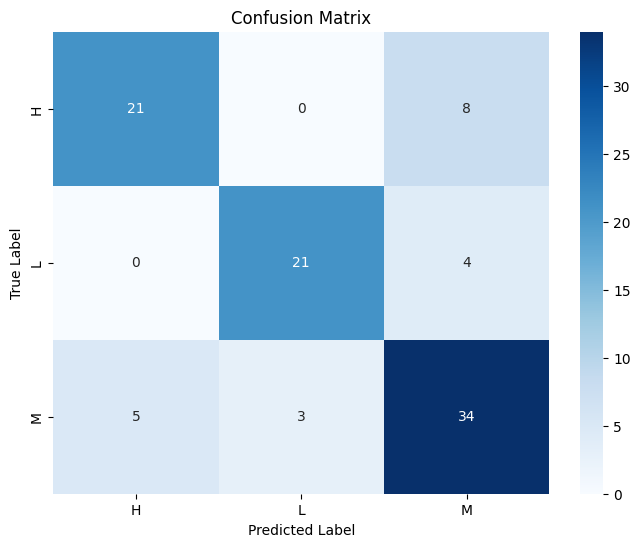

In [17]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 4. Save the Trained Model

To ensure our trained model can be used for future predictions or deployments without retraining, we will save it to disk using the `joblib` library. This is a common practice for machine learning models.

In [18]:
import joblib

# Define the filename for the model
model_filename = 'academic_performance_model.joblib'

# Save the trained model
joblib.dump(model, model_filename)

print(f"Model successfully saved to {model_filename}")

Model successfully saved to academic_performance_model.joblib


In [19]:
!ls -l academic_performance_model_svc.joblib

-rw-r--r-- 1 root root 196483 Sep 22 02:40 academic_performance_model_svc.joblib


## 5. Model Improvement: Hyperparameter Tuning

To further improve the model's performance, we can perform hyperparameter tuning. This involves searching for the optimal combination of parameters for our `RandomForestClassifier`. We'll use `GridSearchCV` to exhaustively search a specified parameter space.

In [20]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
# 'cv=5' means 5-fold cross-validation
# 'scoring="accuracy"' means we optimize for accuracy
# 'n_jobs=-1' uses all available CPU cores
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Performing Grid Search for best hyperparameters...")
grid_search.fit(X_train, y_train)
print("Grid Search complete.")

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Performing Grid Search for best hyperparameters...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Grid Search complete.
Best parameters found: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validation accuracy: 0.8073


### 5.1 Retrain Model with Best Parameters and Re-evaluate

Now that we have the best hyperparameters, we'll retrain our `RandomForestClassifier` with these optimal settings and re-evaluate its performance on the test set.

Tuned Model Accuracy: 0.7708

Classification Report for Tuned Model:
              precision    recall  f1-score   support

           H       0.75      0.72      0.74        29
           L       0.88      0.84      0.86        25
           M       0.73      0.76      0.74        42

    accuracy                           0.77        96
   macro avg       0.78      0.78      0.78        96
weighted avg       0.77      0.77      0.77        96



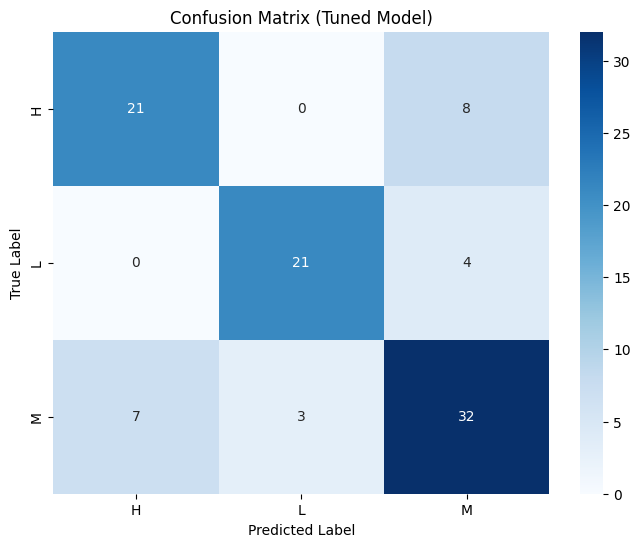

In [21]:
# Get the best model from Grid Search
best_model = grid_search.best_estimator_

# Make predictions with the tuned model
y_pred_tuned = best_model.predict(X_test)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")

print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

# Generate and plot the confusion matrix for the tuned model
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tuned Model)')
plt.show()

## 6. Save the Tuned Model

If the tuned model shows improved performance, it's good practice to save this updated version.

## 7. Alternative Model: GradientBoostingClassifier

Let's try another powerful ensemble classifier, the `GradientBoostingClassifier`, to see if we can achieve better accuracy. Gradient Boosting builds models sequentially, where each new model corrects errors made by previous ones.

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
print("Training the GradientBoostingClassifier...")
gb_model.fit(X_train, y_train)
print("Training complete.")

Training the GradientBoostingClassifier...
Training complete.


### 7.1 Evaluate GradientBoostingClassifier

Now, let's evaluate the performance of our `GradientBoostingClassifier` on the test set.

Gradient Boosting Model Accuracy: 0.7708

Classification Report for Gradient Boosting Model:
              precision    recall  f1-score   support

           H       0.80      0.69      0.74        29
           L       0.81      0.88      0.85        25
           M       0.73      0.76      0.74        42

    accuracy                           0.77        96
   macro avg       0.78      0.78      0.78        96
weighted avg       0.77      0.77      0.77        96



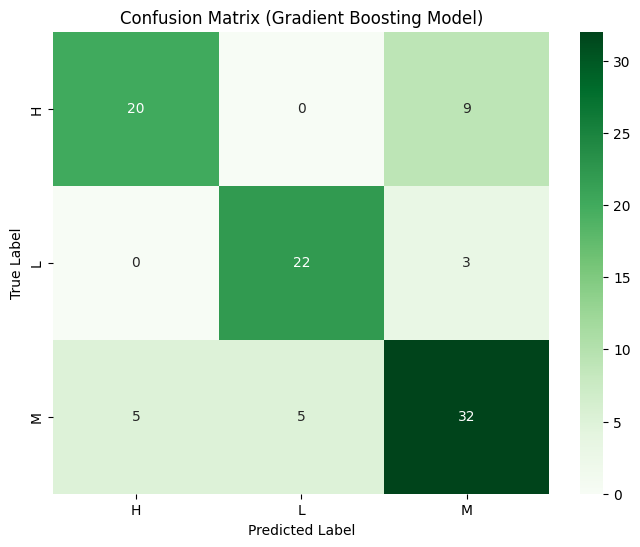

In [23]:
# Make predictions on the test set with Gradient Boosting model
y_pred_gb = gb_model.predict(X_test)

# Calculate accuracy
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Model Accuracy: {accuracy_gb:.4f}")

# Display classification report
print("\nClassification Report for Gradient Boosting Model:")
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))

# Generate and plot the confusion matrix for the Gradient Boosting model
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Gradient Boosting Model)')
plt.show()

## 8. Save the GradientBoostingClassifier Model

Finally, we'll save this new Gradient Boosting model.

In [24]:
# Define the filename for the Gradient Boosting model
model_filename_gb = 'academic_performance_model_gradient_boosting.joblib'

# Save the trained Gradient Boosting model
joblib.dump(gb_model, model_filename_gb)

print(f"Gradient Boosting model successfully saved to {model_filename_gb}")

Gradient Boosting model successfully saved to academic_performance_model_gradient_boosting.joblib


## 9. Alternative Model: XGBoost Classifier

XGBoost (eXtreme Gradient Boosting) is another highly efficient and powerful gradient boosting library that is often used for its superior performance and speed. Let's try training an `XGBClassifier` and evaluating its accuracy.

In [25]:
# Install XGBoost if not already installed
# !pip install xgboost

import xgboost as xgb

# Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax', # For multi-class classification
    num_class=len(le.classes_), # Number of unique classes
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False, # Suppress warning about future removal
    eval_metric='mlogloss',
    random_state=42
)

# Train the model
print("Training the XGBoost Classifier...")
xgb_model.fit(X_train, y_train)
print("Training complete.")

Training the XGBoost Classifier...
Training complete.


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [02:53:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 9.1 Evaluate XGBoost Classifier

Let's evaluate the performance of our `XGBClassifier` on the test set.

XGBoost Model Accuracy: 0.7396

Classification Report for XGBoost Model:
              precision    recall  f1-score   support

           H       0.74      0.59      0.65        29
           L       0.85      0.88      0.86        25
           M       0.68      0.76      0.72        42

    accuracy                           0.74        96
   macro avg       0.76      0.74      0.75        96
weighted avg       0.74      0.74      0.74        96



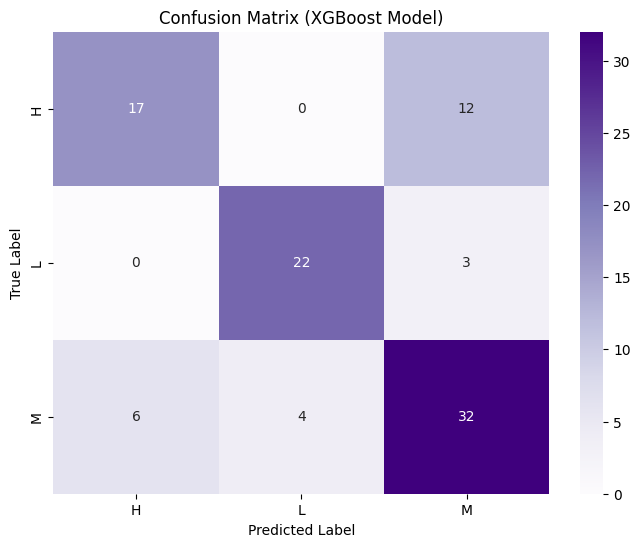

In [26]:
# Make predictions on the test set with XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

# Calculate accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Model Accuracy: {accuracy_xgb:.4f}")

# Display classification report
print("\nClassification Report for XGBoost Model:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# Generate and plot the confusion matrix for the XGBoost model
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (XGBoost Model)')
plt.show()

## 10. Save the XGBoost Classifier Model

Finally, we'll save this new XGBoost model.

In [27]:
# Define the filename for the XGBoost model
model_filename_xgb = 'academic_performance_model_xgboost.joblib'

# Save the trained XGBoost model
joblib.dump(xgb_model, model_filename_xgb)

print(f"XGBoost model successfully saved to {model_filename_xgb}")

XGBoost model successfully saved to academic_performance_model_xgboost.joblib


## 11. Model Improvement: XGBoost Hyperparameter Tuning

Similar to what we did for the RandomForestClassifier, we can perform hyperparameter tuning for our `XGBoostClassifier` to find a better performing model. We'll use `GridSearchCV` to search for optimal parameters.

In [28]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}

# Initialize GridSearchCV for XGBoost
grid_search_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=len(le.classes_),
        use_label_encoder=False, # Suppress warning
        eval_metric='mlogloss',
        random_state=42
    ),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Performing Grid Search for best XGBoost hyperparameters...")
grid_search_xgb.fit(X_train, y_train)
print("Grid Search complete.")

# Print the best parameters and best score
print(f"Best parameters found for XGBoost: {grid_search_xgb.best_params_}")
print(f"Best cross-validation accuracy for XGBoost: {grid_search_xgb.best_score_:.4f}")

Performing Grid Search for best XGBoost hyperparameters...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Grid Search complete.
Best parameters found for XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation accuracy for XGBoost: 0.7969


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [02:54:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 11.1 Retrain XGBoost Model with Best Parameters and Re-evaluate

Now that we have identified the best hyperparameters for XGBoost, let's retrain the model with these parameters and evaluate its performance on the test set.

Tuned XGBoost Model Accuracy: 0.7500

Classification Report for Tuned XGBoost Model:
              precision    recall  f1-score   support

           H       0.73      0.66      0.69        29
           L       0.85      0.88      0.86        25
           M       0.70      0.74      0.72        42

    accuracy                           0.75        96
   macro avg       0.76      0.76      0.76        96
weighted avg       0.75      0.75      0.75        96



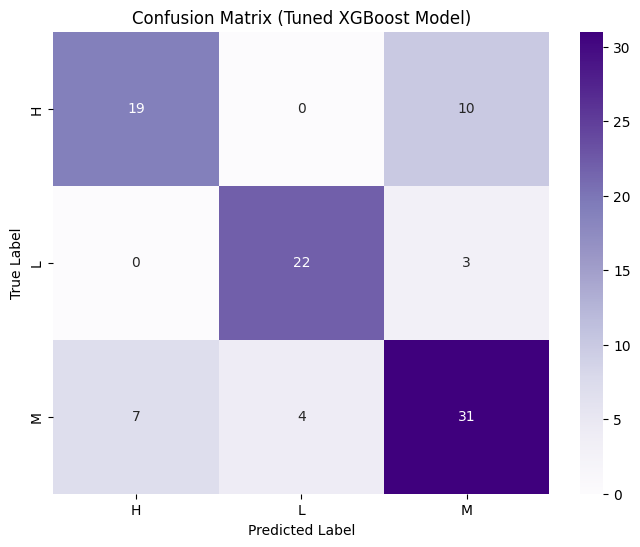

In [29]:
# Get the best XGBoost model from Grid Search
best_xgb_model = grid_search_xgb.best_estimator_

# Make predictions with the tuned XGBoost model
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Evaluate the tuned XGBoost model
accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
print(f"Tuned XGBoost Model Accuracy: {accuracy_xgb_tuned:.4f}")

print("\nClassification Report for Tuned XGBoost Model:")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=le.classes_))

# Generate and plot the confusion matrix for the tuned XGBoost model
conf_matrix_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_tuned, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tuned XGBoost Model)')
plt.show()

## 12. Save the Tuned XGBoost Model

After tuning, we'll save the best performing XGBoost model to ensure it can be reused.

In [30]:
# Define the filename for the tuned XGBoost model
model_filename_xgb_tuned = 'academic_performance_model_xgboost_tuned.joblib'

# Save the tuned XGBoost model
joblib.dump(best_xgb_model, model_filename_xgb_tuned)

print(f"Tuned XGBoost model successfully saved to {model_filename_xgb_tuned}")

Tuned XGBoost model successfully saved to academic_performance_model_xgboost_tuned.joblib


## 13. Alternative Model: Logistic Regression

Let's try a Logistic Regression model. This is a simple yet powerful linear classifier that can serve as a good baseline or provide insights into the linearity of our data.

In [31]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression Classifier
# Using 'liblinear' solver for multi-class problems and 'lbfgs' is also a good general-purpose solver.
# max_iter is increased to ensure convergence.
log_reg_model = LogisticRegression(solver='liblinear', multi_class='auto', random_state=42, max_iter=200)

# Train the model
print("Training the Logistic Regression Classifier...")
log_reg_model.fit(X_train, y_train)
print("Training complete.")

Training the Logistic Regression Classifier...
Training complete.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### 13.1 Evaluate Logistic Regression Model

Now, let's evaluate the performance of our `LogisticRegression` model on the test set.

Logistic Regression Model Accuracy: 0.6771

Classification Report for Logistic Regression Model:
              precision    recall  f1-score   support

           H       0.71      0.52      0.60        29
           L       0.75      0.84      0.79        25
           M       0.62      0.69      0.65        42

    accuracy                           0.68        96
   macro avg       0.69      0.68      0.68        96
weighted avg       0.68      0.68      0.67        96



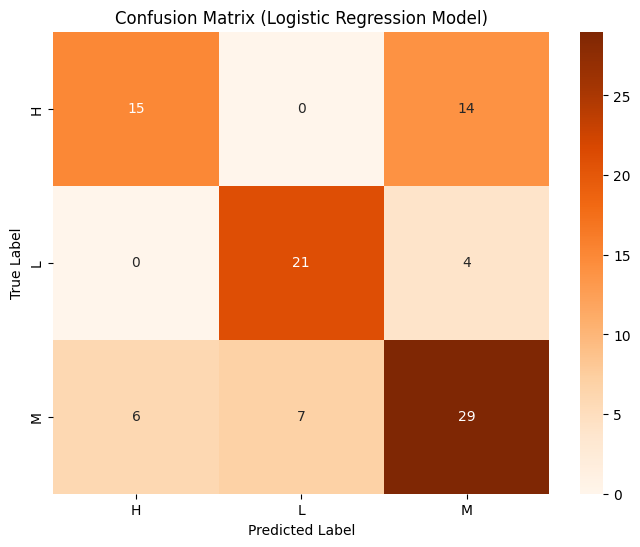

In [32]:
# Make predictions on the test set with Logistic Regression model
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate accuracy
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Model Accuracy: {accuracy_log_reg:.4f}")

# Display classification report
print("\nClassification Report for Logistic Regression Model:")
print(classification_report(y_test, y_pred_log_reg, target_names=le.classes_))

# Generate and plot the confusion matrix for the Logistic Regression model
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Logistic Regression Model)')
plt.show()

## 14. Save the Logistic Regression Model

We'll save the trained Logistic Regression model for future use.

In [33]:
# Define the filename for the Logistic Regression model
model_filename_log_reg = 'academic_performance_model_logistic_regression.joblib'

# Save the trained Logistic Regression model
joblib.dump(log_reg_model, model_filename_log_reg)

print(f"Logistic Regression model successfully saved to {model_filename_log_reg}")

Logistic Regression model successfully saved to academic_performance_model_logistic_regression.joblib


## 15. Alternative Model: Support Vector Machine (SVC)

Let's try a Support Vector Machine (SVC) classifier, which is effective in high-dimensional spaces and cases where the number of dimensions is greater than the number of samples. It can be particularly useful if the data is not linearly separable.

In [34]:
from sklearn.svm import SVC

# Initialize the Support Vector Classifier
# Using 'rbf' kernel as it's a good general-purpose choice, and setting random_state for reproducibility.
svc_model = SVC(kernel='rbf', random_state=42)

# Train the model
print("Training the SVC Classifier...")
svc_model.fit(X_train, y_train)
print("Training complete.")

Training the SVC Classifier...
Training complete.


### 15.1 Evaluate SVC Model

Now, let's evaluate the performance of our `SVC` model on the test set.

SVC Model Accuracy: 0.6146

Classification Report for SVC Model:
              precision    recall  f1-score   support

           H       0.56      0.48      0.52        29
           L       0.72      0.84      0.78        25
           M       0.57      0.57      0.57        42

    accuracy                           0.61        96
   macro avg       0.62      0.63      0.62        96
weighted avg       0.61      0.61      0.61        96



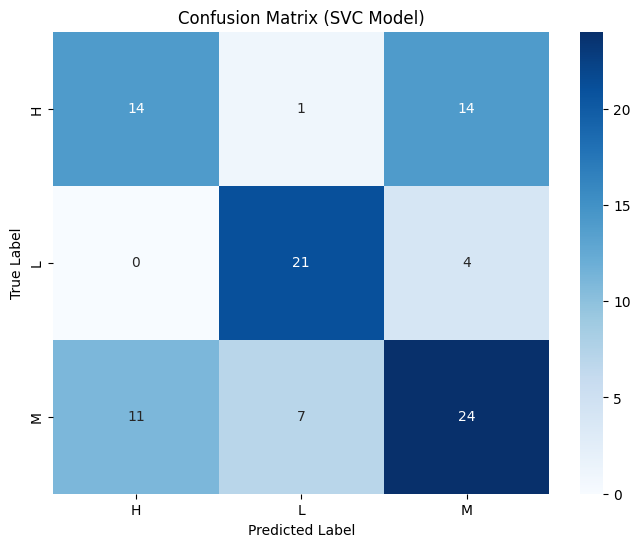

In [35]:
# Make predictions on the test set with SVC model
y_pred_svc = svc_model.predict(X_test)

# Calculate accuracy
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"SVC Model Accuracy: {accuracy_svc:.4f}")

# Display classification report
print("\nClassification Report for SVC Model:")
print(classification_report(y_test, y_pred_svc, target_names=le.classes_))

# Generate and plot the confusion matrix for the SVC model
conf_matrix_svc = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svc, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (SVC Model)')
plt.show()

## 16. Save the SVC Model

We'll save the trained SVC model for future use.

In [36]:
# Define the filename for the SVC model
model_filename_svc = 'academic_performance_model_svc.joblib'

# Save the trained SVC model

joblib.dump(svc_model, model_filename_svc)

print(f"SVC model successfully saved to {model_filename_svc}")

SVC model successfully saved to academic_performance_model_svc.joblib


In [37]:
# Define a new filename for the tuned model
model_filename_tuned = 'academic_performance_model_tuned.joblib'

# Save the tuned model
joblib.dump(best_model, model_filename_tuned)

print(f"Tuned model successfully saved to {model_filename_tuned}")

Tuned model successfully saved to academic_performance_model_tuned.joblib
